<a href="https://colab.research.google.com/github/rashmib21/Data-Analysis-of-Stock-Market-from-2016-to-2026/blob/main/Linear_Regression_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
!pip install odfpy
print("odfpy installed successfully.")

odfpy installed successfully.


## Goal: Predict future stock values for 'open', 'high', 'low', 'close', and 'volume' columns using Linear Regression with time as the input feature.

In [3]:
# Load the data
try:
    df = pd.read_excel('Hindustan_copper.ods', engine='odf')
except FileNotFoundError:
    print("Error: 'Hindustan_copper.ods' not found. Please ensure the file is uploaded.")
    raise

# Assuming the datetime column is named 'Date' or 'datetime'. Let's try to infer.
datetime_column = None
for col in ['Date', 'date', 'datetime', 'Datetime']:
    if col in df.columns:
        datetime_column = col
        break

if datetime_column is None:
    print("Error: Could not find a suitable datetime column (e.g., 'Date', 'date', 'datetime').")
    raise ValueError("No datetime column found.")

# Parse datetime, set as index, sort, and assign business day frequency
df[datetime_column] = pd.to_datetime(df[datetime_column])
df = df.set_index(datetime_column)
df = df.sort_index()
df = df.asfreq('B', method='ffill')

print("Data loaded and preprocessed successfully. Displaying first 5 rows:")
display(df.head())

Data loaded and preprocessed successfully. Displaying first 5 rows:


,symbol,open,high,low,close,volume
datetime,,,,,,
2016-01-04 00:00:00+05:30,HINDALCO,84.20,85.90,80.4,80.75,8706224
2016-01-05 00:00:00+05:30,HINDALCO,82.00,83.95,80.6,82.60,9819068
2016-01-06 00:00:00+05:30,HINDALCO,82.40,82.85,79.7,80.55,6494446
2016-01-07 00:00:00+05:30,HINDALCO,79.00,79.40,76.1,76.65,8098318
2016-01-08 00:00:00+05:30,HINDALCO,77.45,78.15,75.2,76.90,6800939



--- Processing column: open ---
RMSE for open: 14.547
R² Score for open: 0.981


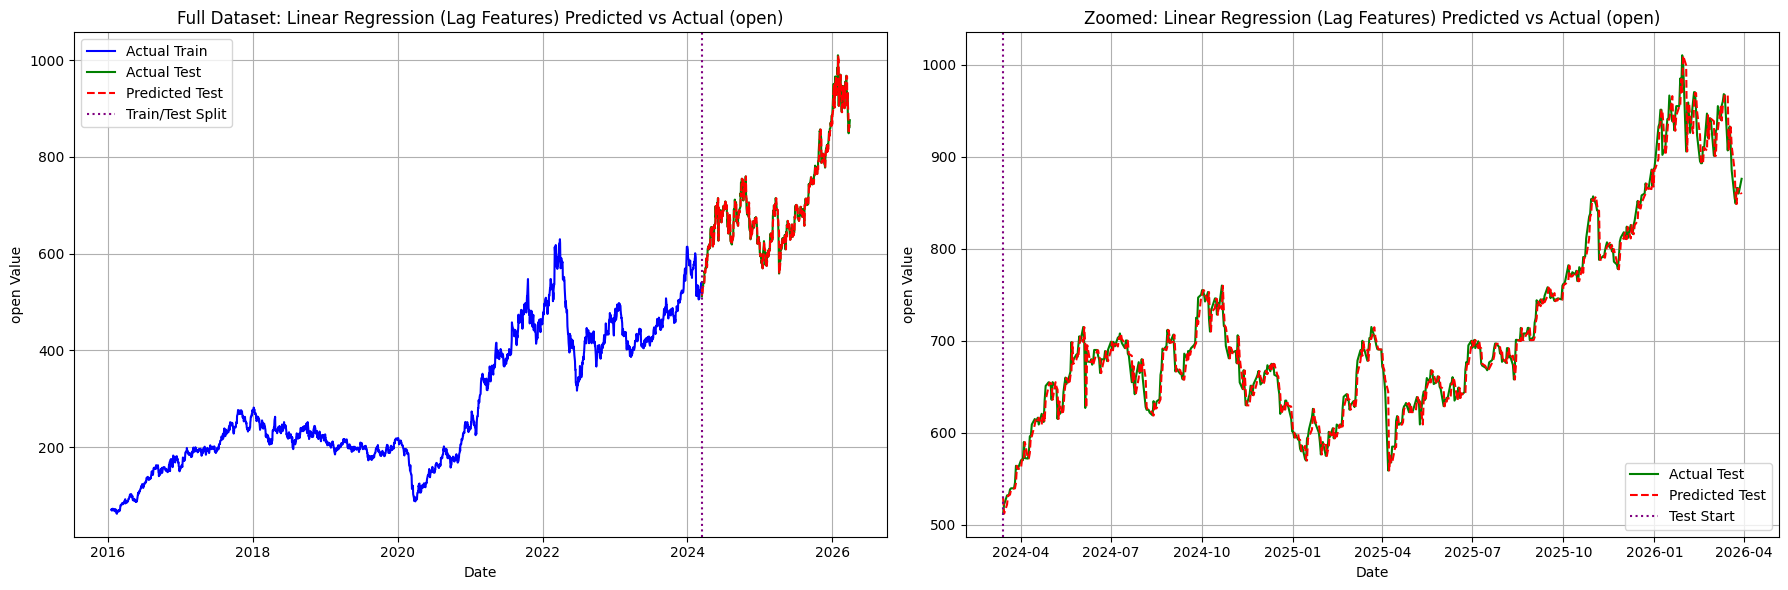


--- Processing column: high ---
RMSE for high: 11.991
R² Score for high: 0.987


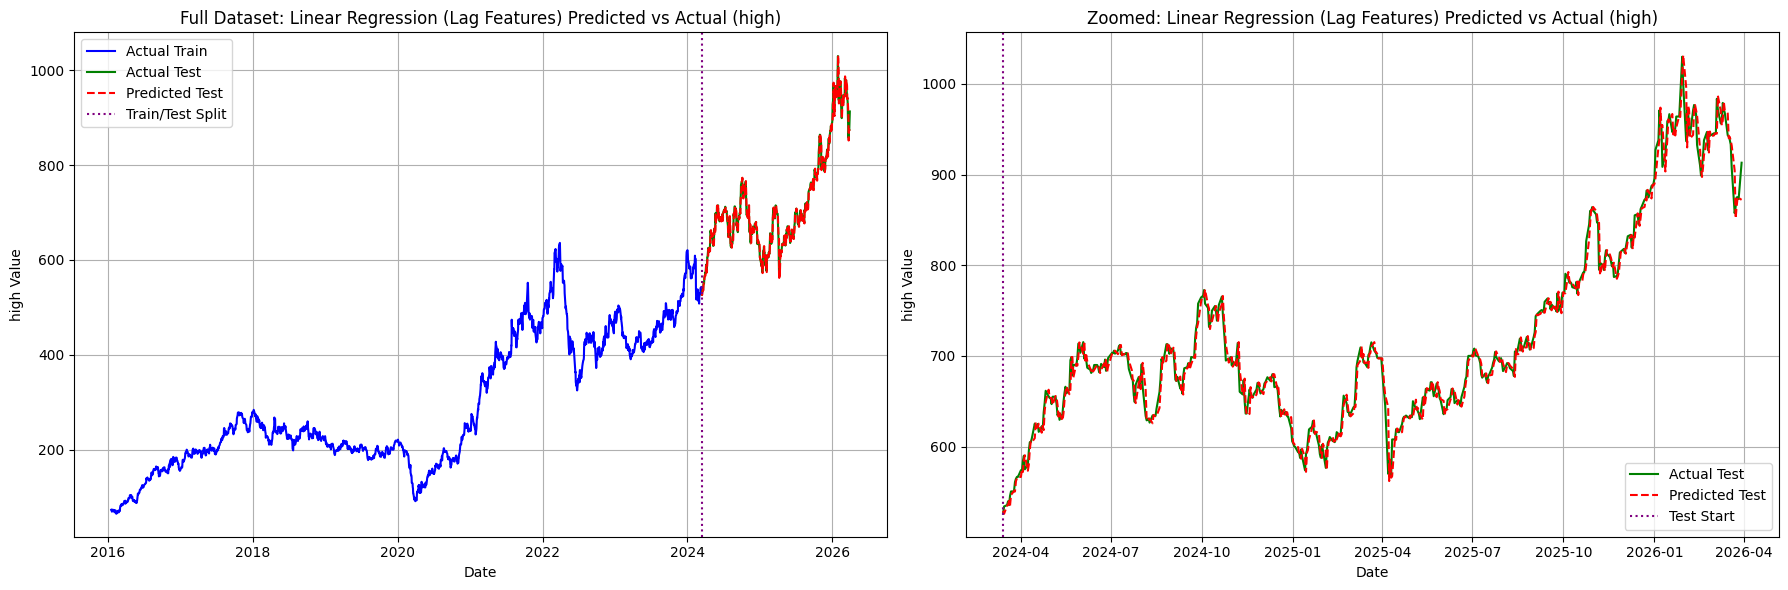


--- Processing column: low ---
RMSE for low: 13.324
R² Score for low: 0.984


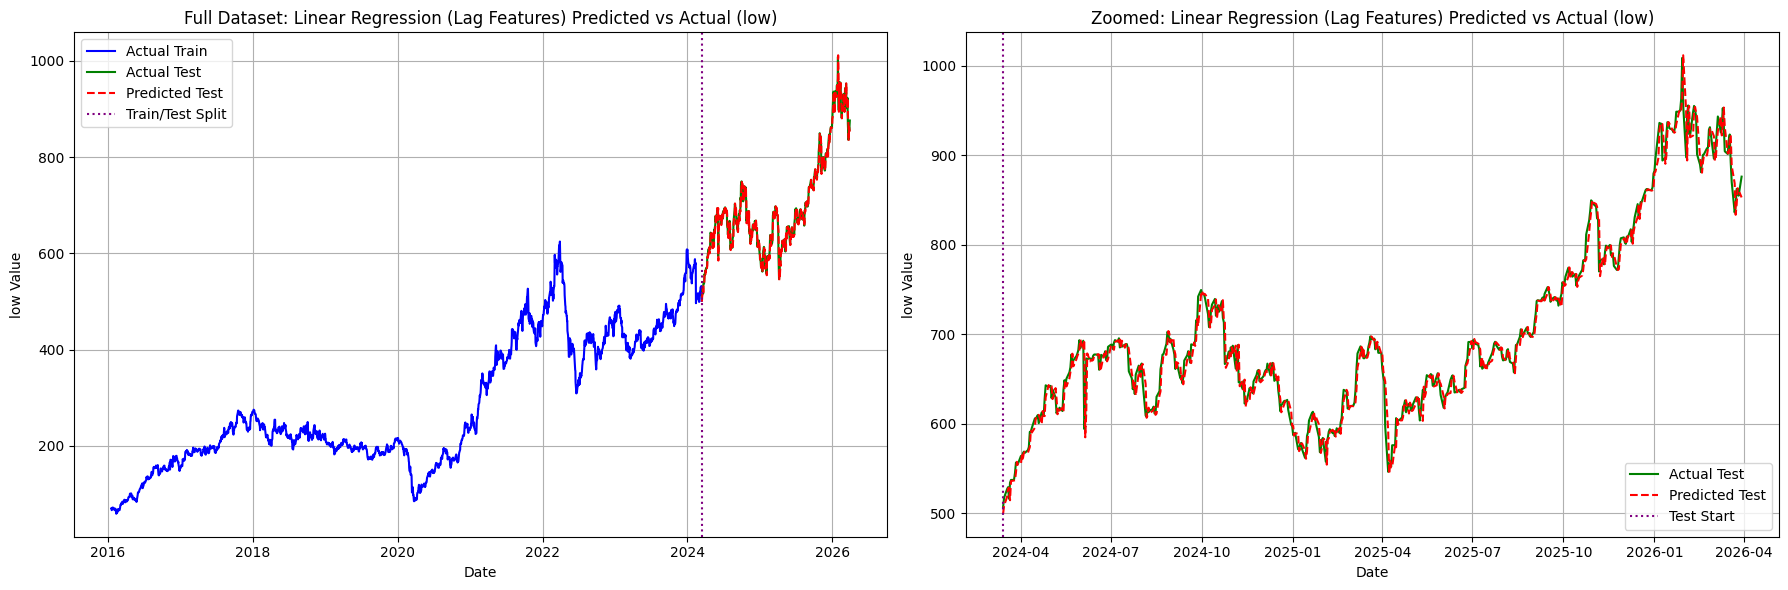


--- Processing column: close ---
RMSE for close: 13.075
R² Score for close: 0.985


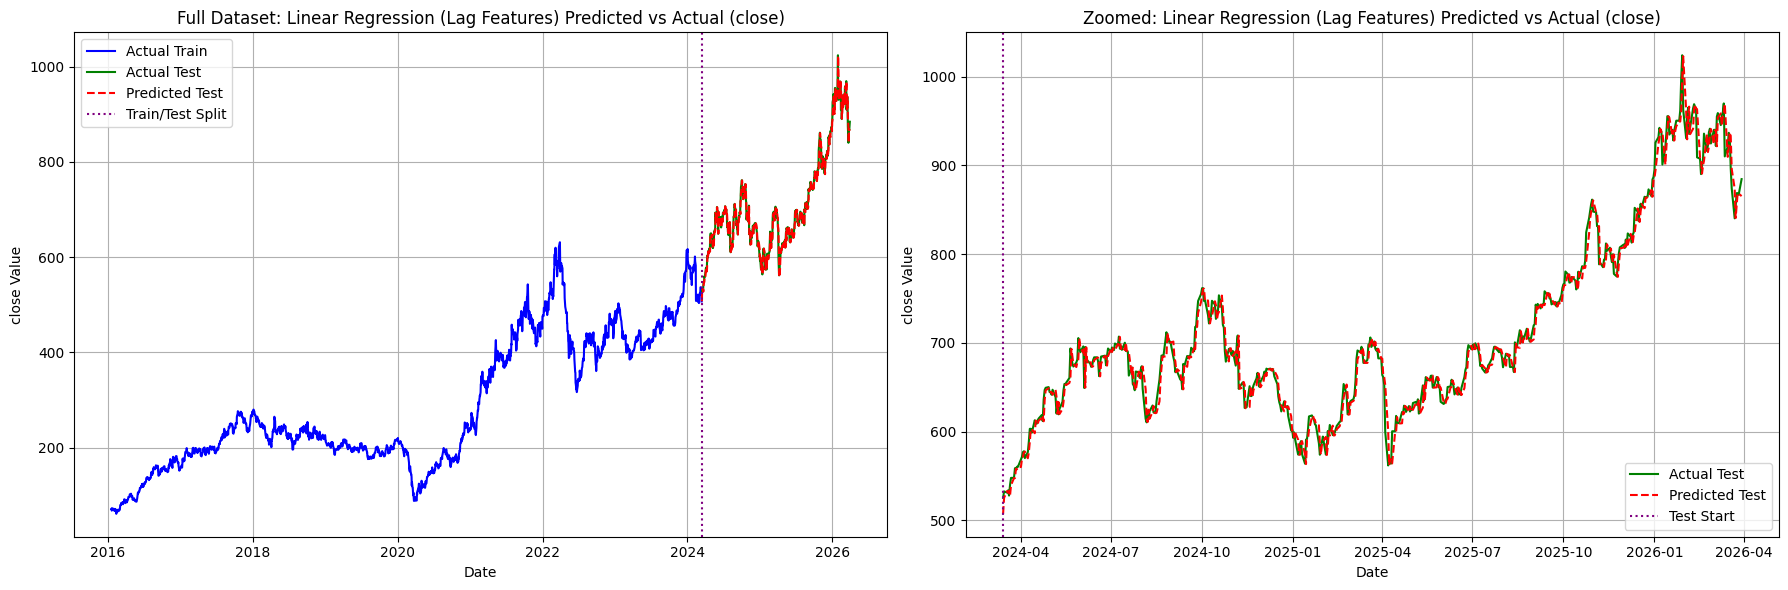


--- Processing column: volume ---
RMSE for volume: 3461387.493
R² Score for volume: 0.092


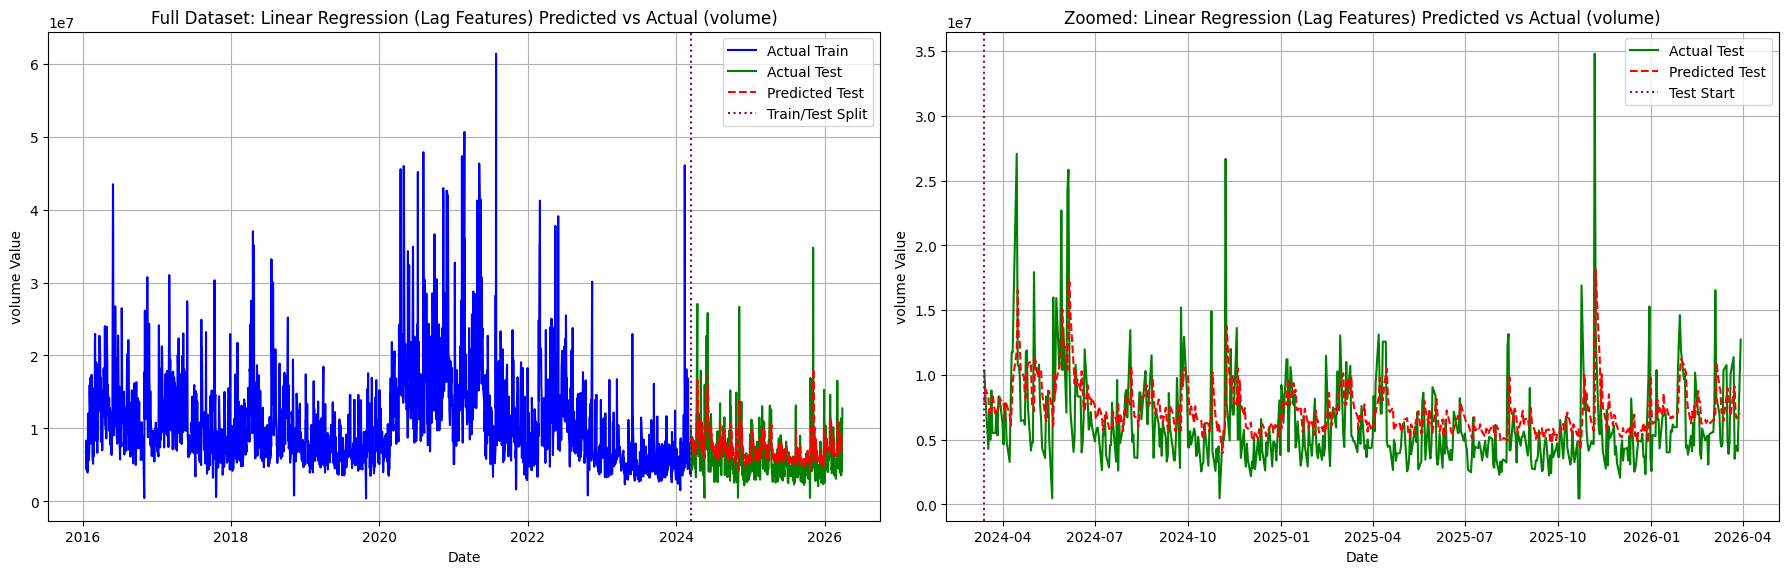

In [7]:
# Columns to process
columns_to_predict = ['open', 'high', 'low', 'close', 'volume']
rmse_results = {}
r2_results = {}

for col in columns_to_predict:
    print(f"\n--- Processing column: {col} ---")

    # Extract the column as the target series
    series = df[col]

    # Create lag features as input variables
    df_lag = pd.DataFrame()
    df_lag['lag_1']  = series.shift(1)
    df_lag['lag_2']  = series.shift(2)
    df_lag['lag_3']  = series.shift(3)
    df_lag['lag_5']  = series.shift(5)
    df_lag['lag_10'] = series.shift(10)
    df_lag['target'] = series.values
    df_lag.dropna(inplace=True)

    X = df_lag[['lag_1', 'lag_2', 'lag_3', 'lag_5', 'lag_10']].values
    y = df_lag['target'].values

    # Split into 80% train and 20% test maintaining time order
    train_size = int(len(X) * 0.8)
    X_train, X_test = X[:train_size], X[train_size:]
    y_train, y_test = y[:train_size], y[train_size:]
    train_index = df_lag.index[:train_size]
    test_index = df_lag.index[train_size:]

    # Fit LinearRegression on training data
    model = LinearRegression()
    model.fit(X_train, y_train)

    # Predict on test data
    y_pred = model.predict(X_test)

    # Calculate and print RMSE and R2 Score
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    rmse_results[col] = rmse
    r2_results[col] = r2
    print(f"RMSE for {col}: {rmse:.3f}")
    print(f"R² Score for {col}: {r2:.3f}")

    # Create a figure with 2 subplots
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))

    # Left - full view
    axes[0].plot(train_index, y_train, color='blue', label='Actual Train')
    axes[0].plot(test_index, y_test, color='green', label='Actual Test')
    axes[0].plot(test_index, y_pred, color='red', linestyle='--', label='Predicted Test')
    axes[0].axvline(train_index[-1], color='purple', linestyle=':', label='Train/Test Split')
    axes[0].set_title(f"Full Dataset: Linear Regression (Lag Features) Predicted vs Actual ({col})")
    axes[0].set_xlabel("Date")
    axes[0].set_ylabel(f"{col} Value")
    axes[0].legend()
    axes[0].grid(True)

    # Right - zoomed test-only view
    axes[1].plot(test_index, y_test, color='green', label='Actual Test')
    axes[1].plot(test_index, y_pred, color='red', linestyle='--', label='Predicted Test')
    axes[1].axvline(test_index[0], color='purple', linestyle=':', label='Test Start')
    axes[1].set_title(f"Zoomed: Linear Regression (Lag Features) Predicted vs Actual ({col})")
    axes[1].set_xlabel("Date")
    axes[1].set_ylabel(f"{col} Value")
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()


In [8]:
# Print final summary table
print("\n--- Final Summary Table ---")
print("Column     | RMSE       | R² Score")
print("-----------|------------|----------")
for col in columns_to_predict:
    rmse = rmse_results[col]
    r2 = r2_results[col]
    print(f"{col:<10} | {rmse:<10.3f} | {r2:.3f}")


--- Final Summary Table ---
Column     | RMSE       | R² Score
-----------|------------|----------
open       | 14.547     | 0.981
high       | 11.991     | 0.987
low        | 13.324     | 0.984
close      | 13.075     | 0.985
volume     | 3461387.493 | 0.092


## Goal: Use open, high, low, volume as input features (exogenous variables) to predict close price using Linear Regression.

In [9]:
# Define input features (X) and target (y)
X = df[['open', 'high', 'low', 'volume']]
y = df['close']

print("Input features (X) and target (y) defined successfully.")

Input features (X) and target (y) defined successfully.


In [10]:
# Split into 80% train and 20% test maintaining time order
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# Get indices for plotting
train_index = y.index[:train_size]
test_index = y.index[train_size:]

print(f"Data split into train ({len(X_train)} samples) and test ({len(X_test)} samples).")

Data split into train (2136 samples) and test (535 samples).


In [11]:
# Fit LinearRegression() from sklearn.linear_model on training data
model = LinearRegression()
model.fit(X_train, y_train)

# Print model coefficients and intercept
print("Feature Coefficients:")
for i, feature in enumerate(X.columns):
    print(f"{feature:<10} : {model.coef_[i]:.3f}")
print(f"{'Intercept':<10} : {model.intercept_:.3f}")

# Predict on test data
y_pred = model.predict(X_test)

print("Model trained and predictions made.")

Feature Coefficients:
open       : -0.577
high       : 0.821
low        : 0.754
volume     : -0.000
Intercept  : 0.249
Model trained and predictions made.


RMSE: 5.169
R² Score: 0.998


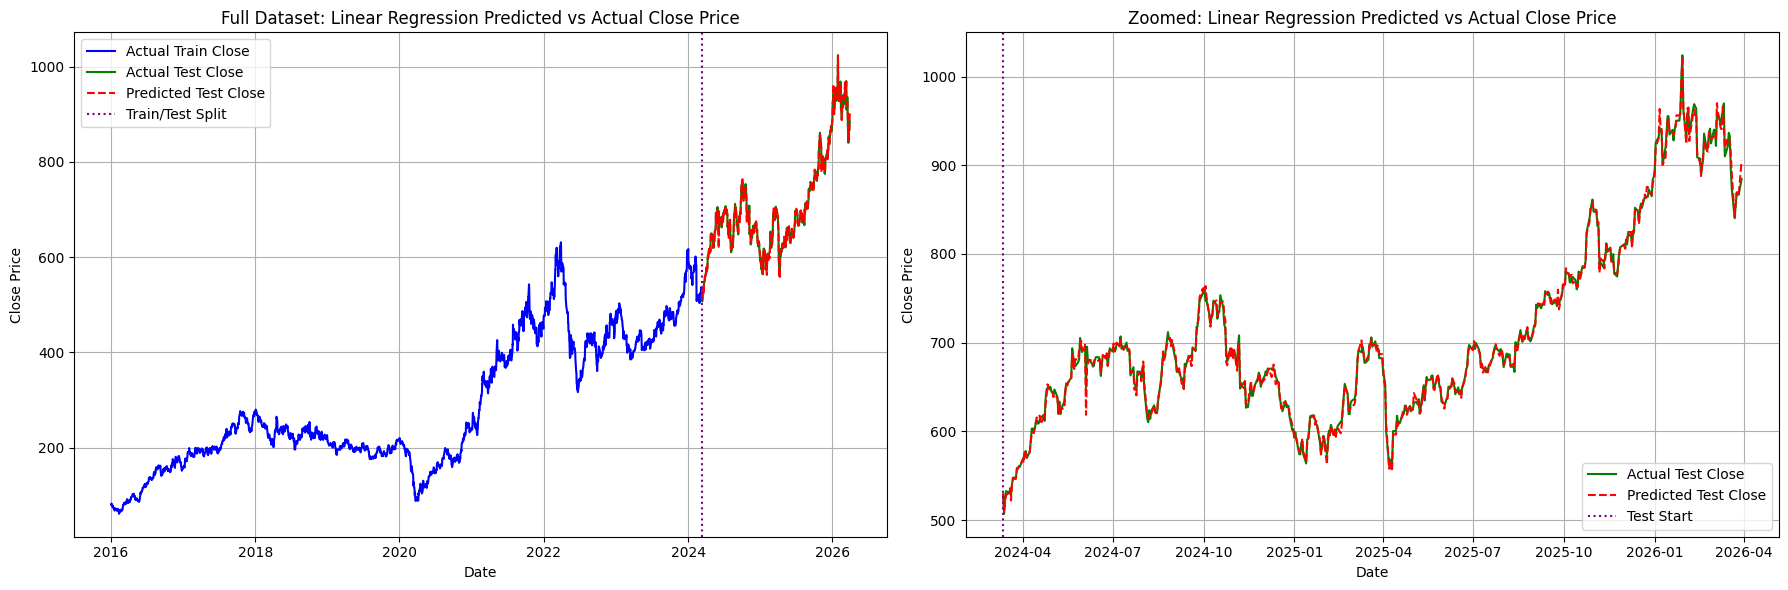

In [12]:
# Calculate and print RMSE and R² Score
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:.3f}")
print(f"R² Score: {r2:.3f}")

# Create a figure with 2 subplots
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Left - full view
axes[0].plot(train_index, y_train, color='blue', label='Actual Train Close')
axes[0].plot(test_index, y_test, color='green', label='Actual Test Close')
axes[0].plot(test_index, y_pred, color='red', linestyle='--', label='Predicted Test Close')
axes[0].axvline(train_index[-1], color='purple', linestyle=':', label='Train/Test Split')
axes[0].set_title("Full Dataset: Linear Regression Predicted vs Actual Close Price")
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Close Price")
axes[0].legend()
axes[0].grid(True)

# Right - zoomed test-only view
axes[1].plot(test_index, y_test, color='green', label='Actual Test Close')
axes[1].plot(test_index, y_pred, color='red', linestyle='--', label='Predicted Test Close')
axes[1].axvline(test_index[0], color='purple', linestyle=':', label='Test Start')
axes[1].set_title("Zoomed: Linear Regression Predicted vs Actual Close Price")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Close Price")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [13]:
# Print final summary
print("\n--- Final Summary ---")
print(f"{'Model':<15} : Linear Regression")
print(f"{'Input Features':<15} : {', '.join(X.columns)}")
print(f"{'Target':<15} : {y.name}")
print(f"{'RMSE':<15} : {rmse:.3f}")
print(f"{'R² Score':<15} : {r2:.3f}")


--- Final Summary ---
Model           : Linear Regression
Input Features  : open, high, low, volume
Target          : close
RMSE            : 5.169
R² Score        : 0.998


## How This is Different From Before
Before (univariate):
past close values → predict close
(only 1 column used)

Now (multivariate):
open + high + low + volume → predict close
(4 columns used together)

Same concept as ARIMAX but using
Linear Regression instead of ARIMA!
The R² score here will tell you how well open, high, low, volume together explain the close price — expect a very high R² (close to 1.0) since these columns are naturally highly correlated with close price!

## Key Difference from ARIMA

**ARIMA**:
*   `previous values → predict next value`
*   (time series pattern based)

**Linear Regression**:
*   `time index (1,2,3...) → predict value`
*   (fits a straight trend line)

Linear Regression will show a straight line trend on the right plot — which is expected and normal. If the actual data curves a lot, the RMSE will be higher than ARIMA. This makes for a great comparison between the two models!